In [ ]:
# Lets import the needed libraries. There are some quick annotations for what the unusual ones are used for.

import csv
import pandas as pd
import numpy as np
import statsmodels.api as sm # For our regression model.
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler # For data normalisation.
import scipy.stats as stats
import matplotlib.dates as mdates # Used for setting date axis (x axis) to only show on sundays so the axis isnt to crowded.

In [ ]:
# Loading our data.

sentiment_by_day_for_avg = pd.read_csv('../Data/Data_Post_Sentiment/sentiment_by_day_for_avg.csv', encoding='utf-8')
sentiment_by_day_for_title = pd.read_csv('../Data/Data_Post_Sentiment/sentiment_by_day_for_title.csv', encoding='utf-8')
sentiment_by_day_for_content = pd.read_csv('../Data/Data_Post_Sentiment/sentiment_by_day_for_content.csv', encoding='utf-8')
All_needed_data = pd.read_csv('../Data/Data_Post_Sentiment/All_needed_data.csv', encoding='utf-8')

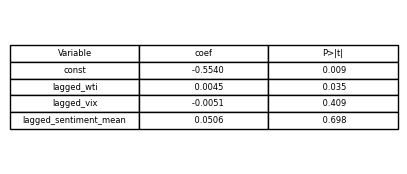

In [ ]:
# Regression 1: Basic exploratory regression
# checking is sentiment is persistant, can oil yesterday move sentiment, and does braoder market fear drive sentiement.

reg1 = All_needed_data.copy()
reg1.dropna(inplace=True) # Wont run if null values.

x1 = reg1[['lagged_wti','lagged_vix','lagged_sentiment_mean']] # Our independent variables  If we use lagged_ovx, we introduce alot of multicolinearity as wti (oil) and ovx (oil volatility)
y1 = reg1['sentiment_mean'] # Our dependent variable

x1 = sm.add_constant(x1)
model1 = sm.OLS(y1, x1).fit()

with open('../Outputs/Table/Regression1_FULL.txt', 'w') as f: # Also saving as a txt so you can veiw the whole thing.
    f.write(str(model1.summary()))

# The below code coverts the regression into dataframe, so that it can be saved as a table png.
# This is so our final output has regression models that automatically update, and dont need to have data manually inputted.
# This option also just looks nicer than dispalyer the full regression output (which is also saved)

table1 = model1.summary().tables[1] # We create a dataframe of the regression variable outputs only
df1 = pd.DataFrame(table1.data[1:], columns=table1.data[0])
df1 = df1[['coef','P>|t|']]
df1.index = ['const', 'lagged_wti', 'lagged_vix', 'lagged_sentiment_mean']
df1 = df1.reset_index().rename(columns={'index': 'Variable'}) # We have to manually add the variable names, and reformate the dataframe to include them.

fig, ax = plt.subplots(figsize=(5, 2)) # Creating a table of the dataframe so we can save it as a png
ax.axis('off')

table = ax.table(cellText=df1.values,colLabels=df1.columns,loc='center', cellLoc='center')

plt.savefig('../Outputs/Table/Regression1.png', bbox_inches='tight', dpi=300, transparent=True)

plt.show()

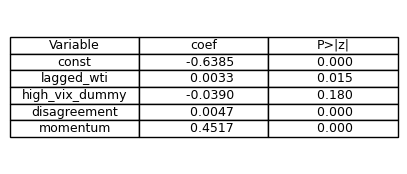

In [ ]:
# Regression 2: Adding dummies and interactive terms.

reg2 = All_needed_data.copy()
reg2.dropna(inplace=True) # Wont run if null values.

reg2['disagreement'] = reg2['sentiment_std'] * reg2['count'] # Disagreement around sentiment.
reg2['momentum'] = reg2['sentiment_mean'] - reg2['lagged_sentiment_mean'] # How fast sentiment changes and its direction.

reg2['high_vix_dummy'] = np.where(reg2['vix'] > 25, 1, 0) # Creating a dummy for higher market fear/volatility.


x2 = reg2[['lagged_wti','high_vix_dummy','disagreement','momentum']]
y2 = reg2['sentiment_mean'] # Our dependent variable.


x2 = sm.add_constant(x2)
model2 = sm.OLS(y2, x2).fit(cov_type='HC3') #Using HC3 as it is better for smaller samples.

with open('../Outputs/Table/Regression2_FULL.txt', 'w') as f: # Also saving as a txt so you can veiw the whole thing.
    f.write(str(model2.summary()))

# The below code coverts the regression into dataframe, so that it can be saved as a table png.
# This is so our final output has regression models that automatically update, and dont need to have data manually inputted.
# This option also just looks nicer than dispalyer the full regression output (which is also saved)

table2 = model2.summary().tables[1] # We create a dataframe of the regression variable outputs only
df2 = pd.DataFrame(table2.data[1:], columns=table2.data[0])
df2 = df2[['coef','P>|z|']]
df2.index = ['const', 'lagged_wti', 'high_vix_dummy', 'disagreement','momentum']
df2 = df2.reset_index().rename(columns={'index': 'Variable'}) # We have to manually add the variable names, and reformate the dataframe to include them.

fig, ax = plt.subplots(figsize=(5, 2)) # Creating a table of the dataframe so we can save it as a png
ax.axis('off')

table = ax.table(cellText=df2.values,colLabels=df2.columns,loc='center', cellLoc='center')

plt.savefig('../Outputs/Table/Regression2.png', bbox_inches='tight', dpi=300, transparent=True)

plt.show()


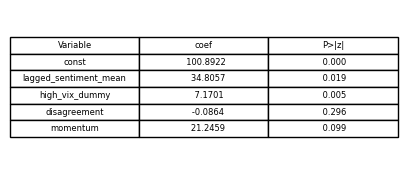

In [ ]:
# Regression 3: Swapping dependent variables.

reg3 = All_needed_data.copy()
reg3.dropna(inplace=True) # Wont run if null values.

reg3['disagreement'] = reg3['sentiment_std'] * reg3['count'] # Disagreement around sentiment.
reg3['momentum'] = reg3['sentiment_mean'] - reg3['lagged_sentiment_mean'] # How fast sentiment changes and its direction.

reg3['high_vix_dummy'] = np.where(reg3['vix'] > 25, 1, 0) # Creating a dummy for higher market fear/volatility.


x3 = reg3[['lagged_sentiment_mean','high_vix_dummy','disagreement','momentum']]
y3 = reg3['wti'] # Our dependent variable has now been switched to wti oil, we are checking if sentiment predicts it.


x3 = sm.add_constant(x3)
model3 = sm.OLS(y3, x3).fit(cov_type='HC3') #Using HC3 as it is better for smaller samples.

with open('../Outputs/Table/Regression3_FULL.txt', 'w') as f: # Also saving as a txt so you can veiw the whole thing.
    f.write(str(model3.summary()))

# The below code coverts the regression into dataframe, so that it can be saved as a table png.
# This is so our final output has regression models that automatically update, and dont need to have data manually inputted.
# This option also just looks nicer than dispalyer the full regression output (which is also saved)

table3 = model3.summary().tables[1] # We create a dataframe of the regression variable outputs only
df3 = pd.DataFrame(table3.data[1:], columns=table3.data[0])
df3 = df3[['coef','P>|z|']]
df3.index = ['const', 'lagged_sentiment_mean', 'high_vix_dummy', 'disagreement','momentum']
df3 = df3.reset_index().rename(columns={'index': 'Variable'}) # We have to manually add the variable names, and reformate the dataframe to include them.

fig, ax = plt.subplots(figsize=(5, 2)) # Creating a table of the dataframe so we can save it as a png
ax.axis('off')

table = ax.table(cellText=df3.values,colLabels=df3.columns,loc='center', cellLoc='center')

plt.savefig('../Outputs/Table/Regression3.png', bbox_inches='tight', dpi=300, transparent=True)

plt.show()

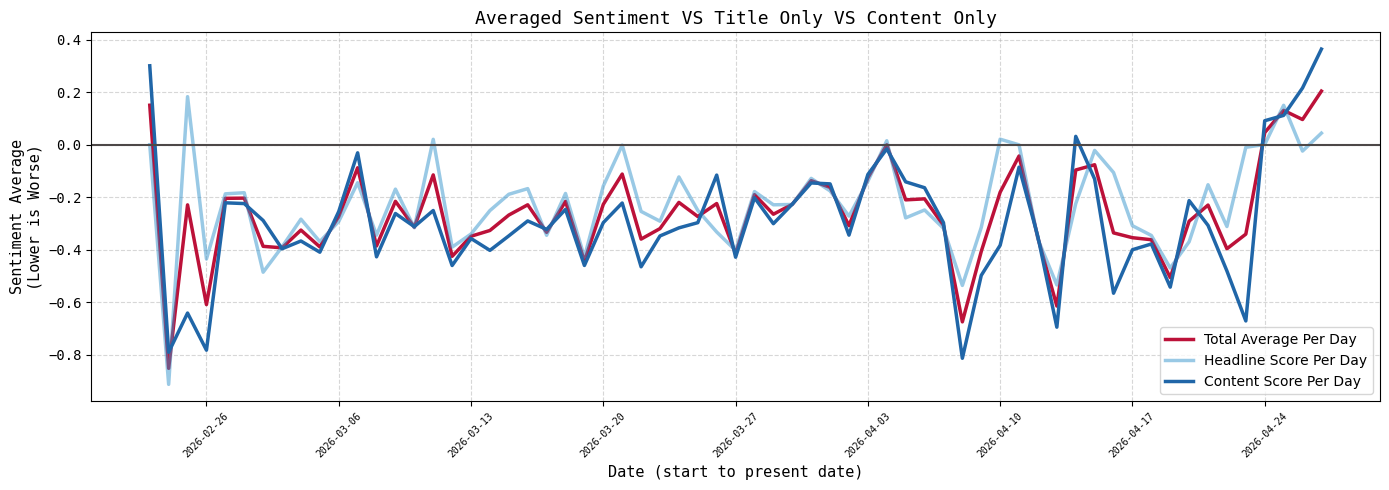

In [13]:
# Graph 1: This is a line graph comparing the sentiment scores if we use titles alone, content alone, or the average of them.

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(sentiment_by_day_for_avg['date'], sentiment_by_day_for_avg['mean'], color='#BC1139', linewidth=2.5, label='Total Average Per Day')
ax1.plot(sentiment_by_day_for_title['date'], sentiment_by_day_for_title['mean'], color='#3594cc', linewidth=2.5, label='Headline Score Per Day',alpha=0.5)
ax1.plot(sentiment_by_day_for_content['date'], sentiment_by_day_for_content['mean'], color='#2066a8', linewidth=2.5, label='Content Score Per Day')

ax1.set_ylabel('Sentiment Average\n(Lower is Worse)', fontsize=11, fontfamily='monospace')
ax1.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')
ax1.legend(loc='lower right')
ax1.axhline(0, color="#4D4848")
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SU))
plt.xticks(rotation=45, fontsize=7, fontfamily='monospace')
plt.yticks(fontfamily='monospace')
plt.grid(linestyle='--', alpha=0.5)

plt.title('Averaged Sentiment VS Title Only VS Content Only', fontsize=13, fontfamily='monospace')
plt.tight_layout()
plt.savefig('../Outputs/Graphs/Sentiments.png', dpi=300, bbox_inches='tight')
plt.show()

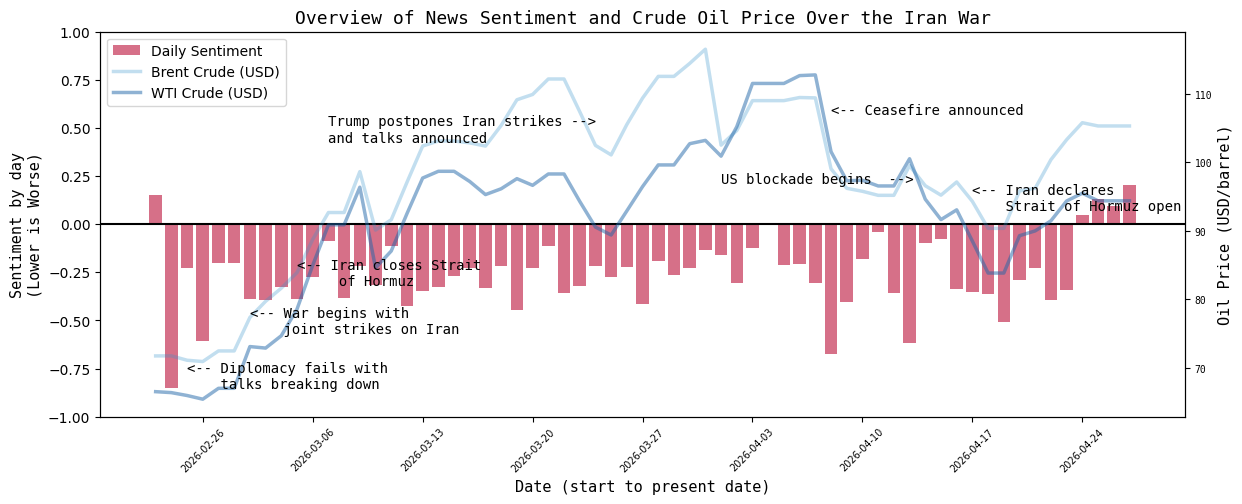

In [8]:
# Graph 2: Overview of oil and sentiment.

fig, ax1 = plt.subplots(figsize=(14,5))

ax1.bar(All_needed_data['date'], All_needed_data['sentiment_mean'], color='#BC1139', width=0.8, label='Daily Sentiment',alpha=0.6)
ax1.axhline(0, color='black')
ax1.set_ylabel('Sentiment by day\n(Lower is Worse)', fontsize=11, fontfamily='monospace')
ax1.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')
ax1.set_ylim(-1, 1)
ax1.tick_params(axis='x', rotation=45, labelsize=7)
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SU))

ax2 = ax1.twinx()
ax2.plot(All_needed_data['date'], All_needed_data['brent'], color='#3594cc', linewidth=2.5, label='Brent Crude (USD)',alpha=0.3)
ax2.plot(All_needed_data['date'], All_needed_data['wti'], color='#2066a8', linewidth=2.5, label='WTI Crude (USD)',alpha=0.5)
ax2.set_ylabel('Oil Price (USD/barrel)', fontsize=11, fontfamily='monospace')
plt.yticks(fontfamily='monospace',fontsize=7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.text(sentiment_by_day_for_avg['date'].iloc[2], 67, '<-- Diplomacy fails with\n    talks breaking down',
         color="#000000", fontsize=10, fontfamily='monospace')

plt.text(sentiment_by_day_for_avg['date'].iloc[6], 75, '<-- War begins with\n    joint strikes on Iran'
         , color="#000000",fontsize=10,fontfamily='monospace')

plt.text(sentiment_by_day_for_avg['date'].iloc[9], 82, '<-- Iran closes Strait\n     of Hormuz',
         color="#000000", fontsize=10, fontfamily='monospace')

plt.text(sentiment_by_day_for_avg['date'].iloc[11], 103, 'Trump postpones Iran strikes -->\nand talks announced',
         color="#000000", fontsize=10, fontfamily='monospace')

plt.text(sentiment_by_day_for_avg['date'].iloc[43], 107, '<-- Ceasefire announced',
         color="#000000", fontsize=10, fontfamily='monospace')

plt.text(sentiment_by_day_for_avg['date'].iloc[36], 97, 'US blockade begins  -->',
         color="#000000", fontsize=10, fontfamily='monospace')

plt.text(sentiment_by_day_for_avg['date'].iloc[52], 93, '<-- Iran declares\n    Strait of Hormuz open',
         color="#000000", fontsize=10, fontfamily='monospace')

plt.title('Overview of News Sentiment and Crude Oil Price Over the Iran War', fontsize=13, fontfamily='monospace')
plt.savefig('../Outputs/Graphs/Overview.png', dpi=300, bbox_inches='tight')
plt.show()



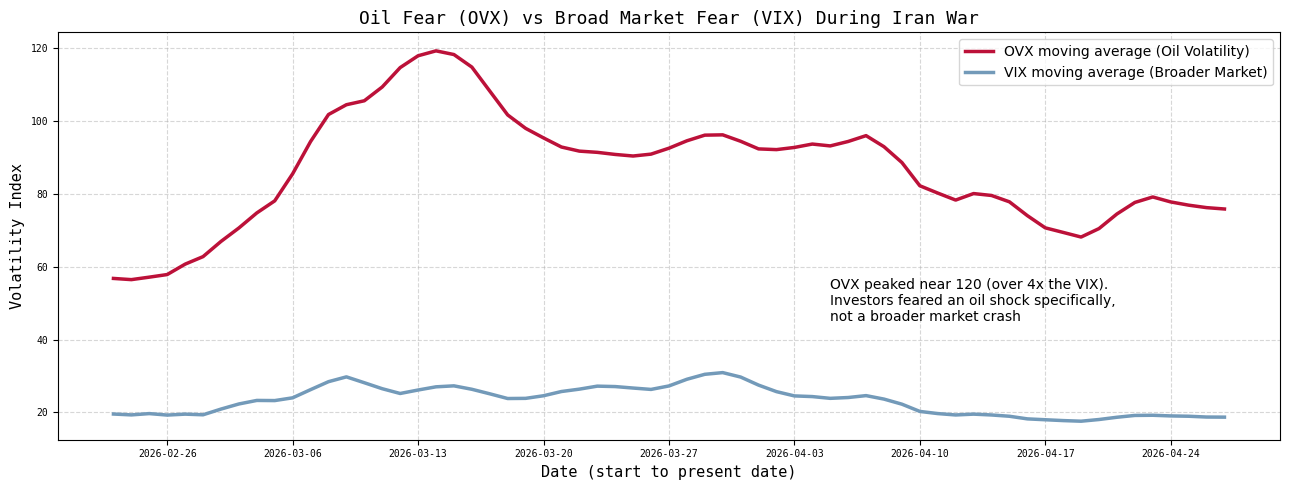

In [14]:
# Graph 3: Comparing oil volatility vs more general market fear.

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(All_needed_data['date'], All_needed_data['ovx_moving_average'], color='#BC1139', linewidth=2.5, label='OVX moving average (Oil Volatility)')
ax.plot(All_needed_data['date'], All_needed_data['vix_moving_average'], color='#739ab9', linewidth=2.5 , label='VIX moving average (Broader Market)')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SU))
ax.set_ylabel('Volatility Index',fontfamily='monospace',fontsize=11)
ax.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')
plt.xticks(fontsize=7, fontfamily='monospace')
plt.yticks(fontfamily='monospace',fontsize=7)


plt.text(All_needed_data['date'].iloc[40], 45, 'OVX peaked near 120 (over 4x the VIX).\nInvestors feared an oil shock specifically,\nnot a broader market crash')

plt.grid(linestyle='--', alpha=0.5)
ax.set_title('Oil Fear (OVX) vs Broad Market Fear (VIX) During Iran War',fontsize=13
             ,fontfamily='monospace')
ax.legend()
plt.tight_layout()

plt.savefig('../Outputs/Graphs/OVX_vs_VIX.png', dpi=300, bbox_inches='tight')
plt.show()

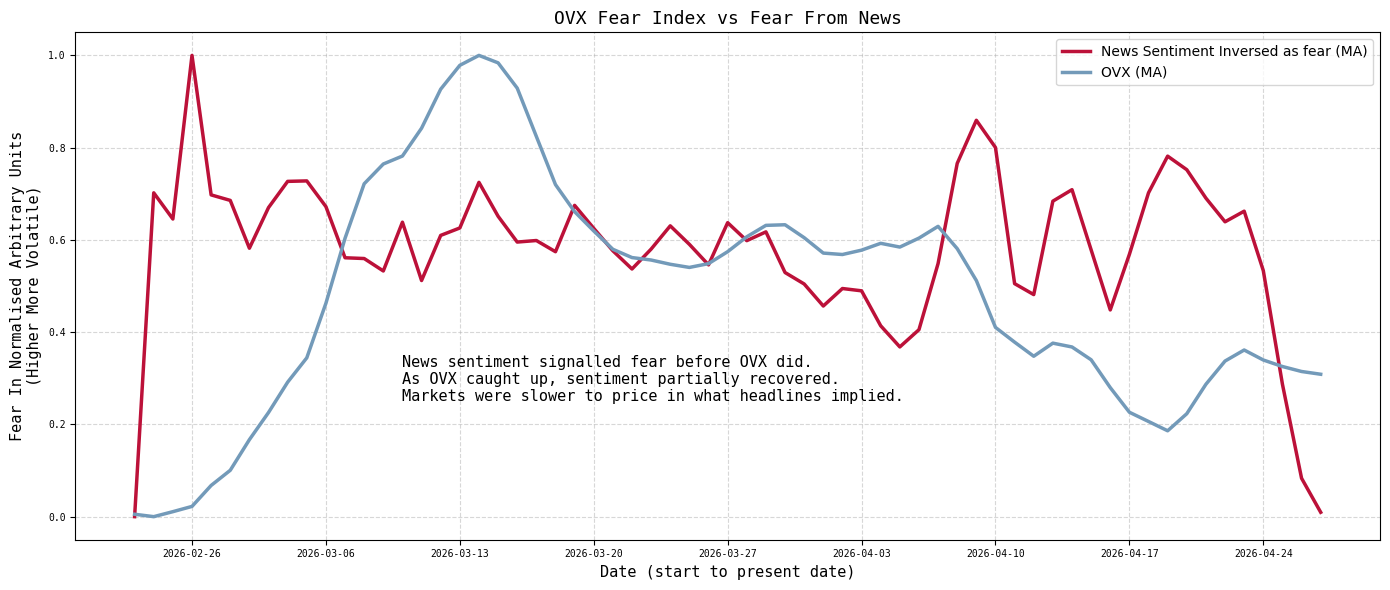

In [10]:
# Graph 4: We compare the OVX index against our measure of fear.

fig, ax = plt.subplots(figsize=(14, 6))

minmax = All_needed_data[['sentiment_mean_moving_average_inversed','ovx_moving_average']]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(minmax.to_numpy())
scaled_data = pd.DataFrame(scaled_data, columns=['scaled_sentiment_mean_moving_average_inversed','scaled_ovx_moving_average'])

ax.plot(All_needed_data['date'], scaled_data['scaled_sentiment_mean_moving_average_inversed'], color='#BC1139', linewidth=2.5, label='News Sentiment Inversed as fear (MA)')
ax.set_ylabel('Fear In Normalised Arbitrary Units\n(Higher More Volatile)', fontsize=11, fontfamily='monospace')
ax.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')
plt.xticks(fontsize=7, fontfamily='monospace')
plt.yticks(fontfamily='monospace',fontsize=7)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SU))

ax.plot(All_needed_data['date'], scaled_data['scaled_ovx_moving_average'], color='#739ab9', linewidth=2.5, label='OVX (MA)')

ax.legend()


plt.text(All_needed_data['date'].iloc[14], 0.25, f'News sentiment signalled fear before OVX did.\nAs OVX caught up, sentiment partially recovered.\nMarkets were slower to price in what headlines implied.'
         , color="#000000",fontsize=11,fontfamily='monospace')

plt.title('OVX Fear Index vs Fear From News', fontsize=13, fontfamily='monospace')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('../Outputs/Graphs/OVX_vs_news_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()


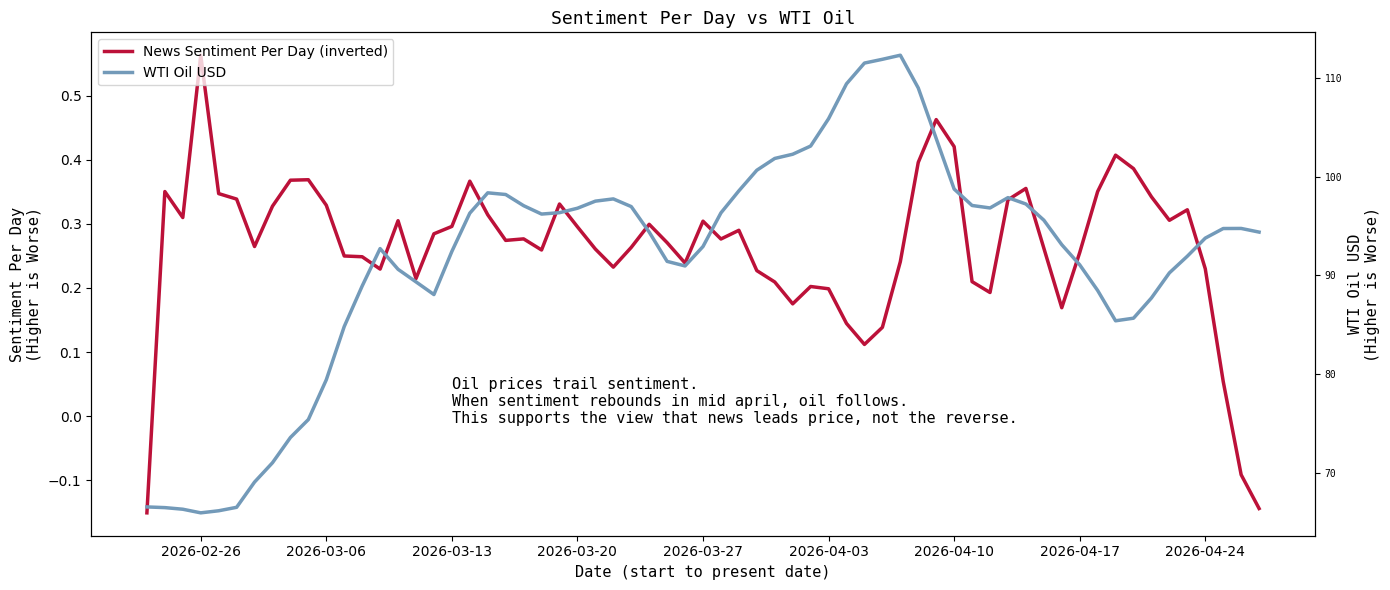

In [11]:
# Graph 5: Exploring sentiment vs lagged WTI oil.

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(All_needed_data['date'], All_needed_data['sentiment_mean_moving_average_inversed'], color='#BC1139', linewidth=2.5, label='News Sentiment Per Day (inverted)')
ax1.set_ylabel('Sentiment Per Day\n(Higher is Worse)', fontsize=11, fontfamily='monospace')
ax1.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')

ax2 = ax1.twinx()
ax2.plot(All_needed_data['date'], All_needed_data['wti_moving_average'], color='#739ab9', linewidth=2.5, label='WTI Oil USD')
ax2.set_ylabel('WTI Oil USD\n(Higher is Worse)', fontsize=11, fontfamily='monospace')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SU))

plt.xticks(fontsize=7, fontfamily='monospace')
plt.yticks(fontfamily='monospace',fontsize=7)

plt.text(All_needed_data['date'].iloc[17], 75, 'Oil prices trail sentiment.\nWhen sentiment rebounds in mid april, oil follows.\nThis supports the view that news leads price, not the reverse.'
         , color="#000000",fontsize=11,fontfamily='monospace')


plt.title('Sentiment Per Day vs WTI Oil', fontsize=13, fontfamily='monospace')
plt.tight_layout()

plt.savefig('../Outputs/Graphs/Sentiment_vs_wti.png', dpi=300, bbox_inches='tight')
plt.show()
